## Cell 1 – Setup (same as before)

In [2]:
! pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 975.0 kB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=2b34b66d6b4cf91996802c09d515ffc56c72e80e244d3b855df2bc37fc72c837
  Stored in directory: /root/.cache/pip/wheels/05/bd/e2/0c0eecf3c26b6cdb231b5656d53905bddc8090d69619d57e6b
Successfully built grad-cam


In [3]:
import os
import random
import re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize

import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Cell 2 – Configuration

In [12]:
class Config:
    # Exact Kaggle input root
    DATA_ROOT = Path("/kaggle/input/datasets/asmaasaad/king-abdulaziz-university-mammogram-dataset")
    
    # Explicit mapping from the actual folder names to class indices
    # (handles the inconsistent capitalization and nested folder names)
    CLASS_FOLDERS = {
        "BIRAD1/b1": 0,          # BI-RADS 1
        "Birad3/b3": 1,          # BI-RADS 3
        "Birad4/b4": 2,          # BI-RADS 4
        "Birad5/Birad5": 3,      # BI-RADS 5
    }
    
    CLASS_NAMES = ["BI-RADS 1", "BI-RADS 3", "BI-RADS 4", "BI-RADS 5"]
    NUM_CLASSES = 4
    
    IMG_SIZE = 384
    BATCH_SIZE = 16
    NUM_EPOCHS = 30
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS = 4               # set to 2 if you get worker errors on Kaggle

cfg = Config()

## Cell 3 – Patient-Aware Discovery + Stratified Group Split

In [19]:
def extract_patient_id(filename: str) -> str:
    """
    Extract unique patient ID from filenames like:
    2013_BC003026_CC_L.jpg  →  BC003026
    """
    stem = Path(filename).stem
    match = re.search(r'(BC\d+)', stem, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback
    parts = stem.split('_')
    if len(parts) >= 2:
        return parts[1].upper()
    return stem

def discover_images(root: Path, class_folders: dict):
    """
    Walks the exact nested structure provided by the user.
    class_folders maps relative paths (e.g. "BIRAD1/b1") → integer label.
    """
    samples = []
    
    for rel_path, label in class_folders.items():
        folder = root / rel_path
        if not folder.exists():
            print(f"⚠ Warning: folder not found → {folder}")
            continue
            
        # Collect all common image extensions
        image_files = []
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
            image_files.extend(folder.glob(ext))
        
        print(f"Found {len(image_files):4d} images in {rel_path}")
        
        for img_path in image_files:
            pid = extract_patient_id(img_path.name)
            samples.append({
                "path": str(img_path),
                "label": label,
                "patient_id": pid,
                "folder": rel_path
            })
    
    if not samples:
        raise RuntimeError(
            "No images found. Please double-check DATA_ROOT and the CLASS_FOLDERS mapping."
        )
    
    df = pd.DataFrame(samples)
    
    print("\n=== Image counts per class ===")
    print(df["label"].value_counts().sort_index())
    
    print("\n=== Unique patients per class ===")
    print(df.groupby("label")["patient_id"].nunique().sort_index())
    
    print(f"\nTotal images      : {len(df)}")
    print(f"Unique patients  : {df['patient_id'].nunique()}")
    
    return df

# ---------- Run discovery ----------
df = discover_images(cfg.DATA_ROOT, cfg.CLASS_FOLDERS)

# ---------- PATIENT-LEVEL STRATIFIED SPLIT ----------
# One representative label per patient (majority vote)
patient_labels = (
    df.groupby("patient_id")["label"]
      .agg(lambda x: x.mode()[0])
      .reset_index()
)

# 70 % train / 15 % val / 15 % test  (strictly patient-level)
train_patients, temp_patients = train_test_split(
    patient_labels["patient_id"],
    test_size=0.60,
    stratify=patient_labels["label"],
    random_state=SEED
)

# val_patients, test_patients = train_test_split(
#     temp_patients,
#     test_size=0.50,
#     stratify=patient_labels.set_index("patient_id").loc[temp_patients]["label"],
#     random_state=SEED
# )



val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.60,
    stratify=patient_labels.set_index("patient_id").loc[temp_patients]["label"],
    random_state=SEED
)

train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print("\n=== Final split (patient-level, zero leakage) ===")
print(f"Train : {len(train_df):4d} images | {train_df['patient_id'].nunique():3d} patients")
print(f"Val   : {len(val_df):4d} images | {val_df['patient_id'].nunique():3d} patients")
print(f"Test  : {len(test_df):4d} images | {test_df['patient_id'].nunique():3d} patients")

# Hard safety checks
assert len(set(train_df.patient_id) & set(val_df.patient_id)) == 0
assert len(set(train_df.patient_id) & set(test_df.patient_id)) == 0
assert len(set(val_df.patient_id)   & set(test_df.patient_id)) == 0
print("Patient leakage check passed – no overlapping patients between splits.")

Found 1865 images in BIRAD1/b1
Found  387 images in Birad3/b3
Found  102 images in Birad4/b4
Found   24 images in Birad5/Birad5

=== Image counts per class ===
label
0    1865
1     387
2     102
3      24
Name: count, dtype: int64

=== Unique patients per class ===
label
0    406
1     97
2     33
3      9
Name: patient_id, dtype: int64

Total images      : 2378
Unique patients  : 512

=== Final split (patient-level, zero leakage) ===
Train :  912 images | 204 patients
Val   :  589 images | 123 patients
Test  :  877 images | 185 patients
Patient leakage check passed – no overlapping patients between splits.


## Cell 4 – Dataset + Transforms (unchanged logic, minor cleanup)

In [20]:
class MammogramDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]["path"]
        label = int(self.df.iloc[idx]["label"])
        
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(path)
        
        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        if self.transform:
            img = self.transform(image=img)["image"]
        
        return img, label

train_transform = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_ds = MammogramDataset(train_df, train_transform)
val_ds   = MammogramDataset(val_df,   val_transform)
test_ds  = MammogramDataset(test_df,  val_transform)

# Class weights still computed on the *image* level of the training set
class_counts = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_df["label"].values]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Cell 5 – Model (same)

In [21]:
def create_model(num_classes):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = create_model(cfg.NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)
optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.NUM_EPOCHS)

## Cell 6 – Training Loop (same as before)

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (running_loss / len(loader.dataset),
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(cfg.NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_labels, _ = evaluate(model, val_loader, criterion, device)
    val_acc = 100. * (val_preds == val_labels).mean()
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1:02d} | Train {train_loss:.4f}/{train_acc:.2f}% | "
          f"Val {val_loss:.4f}/{val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mammogram_model_patient_split.pth")
        print("  → Saved best model")

print(f"Best validation accuracy: {best_val_acc:.2f}%")

  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 01 | Train 0.5536/46.38% | Val 1.3594/36.50%
  → Saved best model


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 02 | Train 0.2571/53.40% | Val 1.4624/49.07%
  → Saved best model


  0%|          | 0/57 [00:00<?, ?it/s]

...

Epoch 28 | Train 0.0889/80.92% | Val 0.9160/79.29%


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 29 | Train 0.0967/83.33% | Val 0.8866/79.63%


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 30 | Train 0.0867/83.22% | Val 0.9889/77.93%
Best validation accuracy: 80.31%


## Cell 7 – Test Evaluation


=== Classification Report (Patient-level split) ===
              precision    recall  f1-score   support

   BI-RADS 1     0.9983    0.8288    0.9057       701
   BI-RADS 3     0.4667    0.8235    0.5957       136
   BI-RADS 4     0.1087    0.1667    0.1316        30
   BI-RADS 5     1.0000    0.9000    0.9474        10

    accuracy                         0.8062       877
   macro avg     0.6434    0.6798    0.6451       877
weighted avg     0.8854    0.8062    0.8316       877



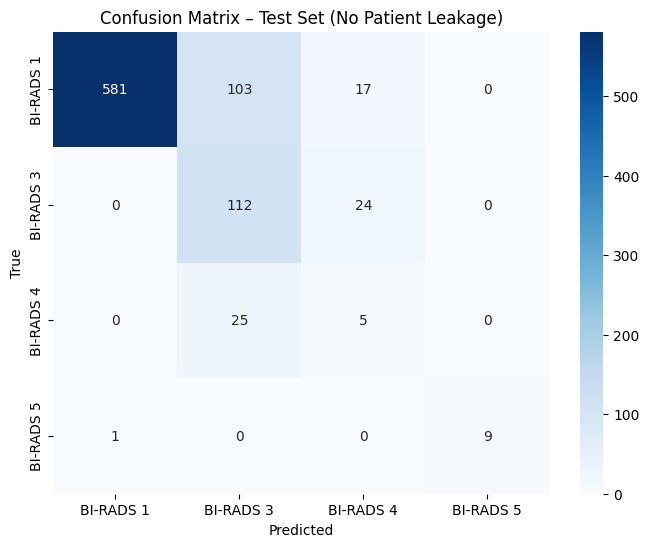


Per-class AUC (OvR):
  BI-RADS 1: 0.9411
  BI-RADS 3: 0.9017
  BI-RADS 4: 0.8487
  BI-RADS 5: 1.0000
Macro AUC: 0.9229


In [24]:
model.load_state_dict(torch.load("best_mammogram_model_patient_split.pth", map_location=device))
test_loss, test_preds, test_labels, test_probs = evaluate(model, test_loader, criterion, device)

print("\n=== Classification Report (Patient-level split) ===")
print(classification_report(test_labels, test_preds, target_names=cfg.CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES)
plt.title("Confusion Matrix – Test Set (No Patient Leakage)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

y_bin = label_binarize(test_labels, classes=range(cfg.NUM_CLASSES))
aucs = roc_auc_score(y_bin, test_probs, average=None, multi_class="ovr")
print("\nPer-class AUC (OvR):")
for name, auc in zip(cfg.CLASS_NAMES, aucs):
    print(f"  {name}: {auc:.4f}")
print(f"Macro AUC: {aucs.mean():.4f}")

## Cell 8 – XAI: Grad-CAM + Grad-CAM++

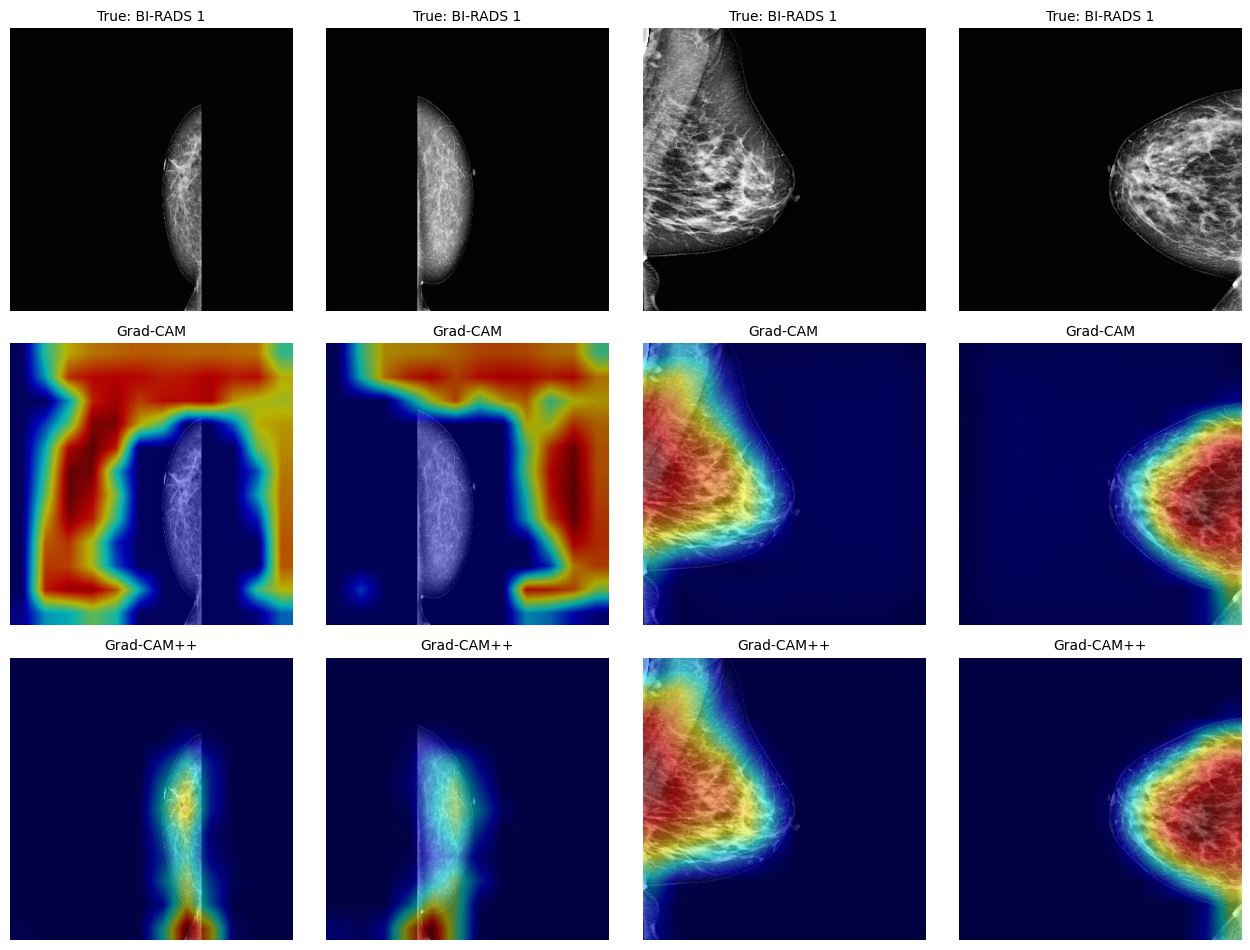

In [25]:
# Target the last convolutional block of EfficientNet-B0
target_layers = [model.features[-1]]

# Two complementary methods
cam_gradcam   = GradCAM(model=model, target_layers=target_layers)
cam_gradcampp = GradCAMPlusPlus(model=model, target_layers=target_layers)

def visualize_xai(dataset, indices, model, cams, class_names, device, n=4):
    """
    cams = list of (name, cam_object)
    """
    model.eval()
    n_methods = len(cams)
    fig, axes = plt.subplots(1 + n_methods, n, figsize=(3.2*n, 3.2*(1+n_methods)))
    
    for col, idx in enumerate(indices[:n]):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        
        # Denormalize for display
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        # Original
        axes[0, col].imshow(img_np)
        axes[0, col].set_title(f"True: {class_names[label]}", fontsize=10)
        axes[0, col].axis("off")
        
        targets = [ClassifierOutputTarget(label)]
        
        for row, (name, cam) in enumerate(cams, start=1):
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
            cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
            axes[row, col].imshow(cam_image)
            axes[row, col].set_title(name, fontsize=10)
            axes[row, col].axis("off")
    
    plt.tight_layout()
    plt.savefig("xai_gradcam_gradcampp.png", dpi=300, bbox_inches="tight")
    plt.show()

# Example visualization
sample_indices = list(range(min(8, len(test_ds))))
visualize_xai(
    test_ds, 
    sample_indices, 
    model, 
    cams=[("Grad-CAM", cam_gradcam), ("Grad-CAM++", cam_gradcampp)],
    class_names=cfg.CLASS_NAMES, 
    device=device, 
    n=4
)

## Cell 9 – Save predictions with patient IDs

In [29]:
results = test_df.copy()
results["pred"] = test_preds
results["prob_max"] = test_probs.max(axis=1)
for i, name in enumerate(cfg.CLASS_NAMES):
    results[f"prob_{name}"] = test_probs[:, i]
results.to_csv("test_predictions_patient_level.csv", index=False)
print("Saved test_predictions_patient_level.csv")

Saved test_predictions_patient_level.csv
